# Notebook 3 – Autoencoder zur Anomalieerkennung
**Maschinelles Lernen mit Python · Kapitel 12: Anomalieerkennung**

---

## Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- die **Architektur eines Autoencoders** (Encoder, Bottleneck, Decoder) beschreiben
- erklären, wie Anomalien anhand des **Rekonstruktionsfehlers** erkannt werden
- den **Schwellwert (Threshold)** verstehen und seinen Einfluss auf Recall/Precision analysieren
- begründen, warum der Autoencoder ein **semi-supervised** Ansatz ist
- die drei Anomalieerkennungsansätze kritisch miteinander vergleichen

---

## Kontext: Warum ein Autoencoder?

Bisher haben wir **überwachte** Methoden verwendet: XGBoost trainiert mit echten Betrugslabels.
Der Autoencoder geht anders vor – er ist **semi-supervised**:
- Training **nur** auf normalen Transaktionen (keine Betrugsfälle nötig!)
- Er lernt, normale Muster zu rekonstruieren
- Bei Anomalien (Betrug) ist der Rekonstruktionsfehler hoch

**Praxisvorteil:** In der Realität hat man oft wenige oder keine gelabelten Betrugsfälle.

> **Verbindung zu den Folien:** Abschnitt Autoencoder-Architektur · Merksatz: *Der Autoencoder ist semi-supervised: nur normale Daten beim Training – Anomalien werden durch hohen Rekonstruktionsfehler erkannt, ohne jemals gesehen worden zu sein.*

---
## Architektur des Autoencoders

```
Input (29 Features)
       |
   [Encoder]
   Dense(20, sigmoid)
   Dense(10, sigmoid)
   Dense( 5, sigmoid)  <- Bottleneck / Latent Space
       |
   [Decoder]
   Dense(10, sigmoid)
   Dense(20, sigmoid)
   Dense(29, sigmoid)  <- Rekonstruktion
       |
Output (29 Features, Rekonstruktion)
```

**Encoder:** Komprimiert 29 Features schrittweise auf 5 (= Bottleneck)
**Bottleneck:** Zwingt das Netz, nur das Wesentliche zu behalten
**Decoder:** Rekonstruiert aus 5 Werten wieder 29 Features
**Verlustfunktion:** MAE (Mean Absolute Error) zwischen Input und Output

---
## Schritt 1: Bibliotheken importieren

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, mean_absolute_error)
from keras.models import Model

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


---
## Schritt 2: Daten laden und vorverarbeiten

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os

base_notebook_dir = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data"
path = os.path.join(base_notebook_dir, "creditcard.csv")
data = pd.read_csv(path, delimiter=',')
print(f"Datensatz: {data.shape[0]:,} Transaktionen, {data.shape[1]} Spalten")

Mounted at /content/drive
Datensatz: 284,807 Transaktionen, 31 Spalten


In [3]:
# Amount normieren (Time wird entfernt - zeitliche Reihenfolge nicht relevant)
s_scaler = StandardScaler()
data['Amount'] = s_scaler.fit_transform(data[['Amount']])
data.drop(['Time'], axis=1, inplace=True)

print("Vorverarbeitung:")
print("  Time-Spalte entfernt")
print("  Amount-Spalte standardisiert (Mittelwert=0, StdAbw=1)")
print(f"  Verbleibende Features: {data.shape[1]-1} (+ Zielspalte Class)")

# Train/Test-Split VOR der Selektion auf normale Daten
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Zielspalte fuer Testdaten separat speichern
test_col  = test_data['Class'].values
test_data = test_data.drop(['Class'], axis=1)

# Autoencoder trainiert NUR auf normalen Transaktionen!
train_data = train_data[train_data['Class'] == 0]
train_data = train_data.drop(['Class'], axis=1)

print(f"Trainingsdaten (nur normal): {train_data.shape[0]:,} Transaktionen")
print(f"Testdaten (gemischt):        {len(test_data):,} Transaktionen")
print(f"  davon Betrug im Test:      {test_col.sum()} ({test_col.sum()/len(test_col)*100:.3f}%)")

Vorverarbeitung:
  Time-Spalte entfernt
  Amount-Spalte standardisiert (Mittelwert=0, StdAbw=1)
  Verbleibende Features: 29 (+ Zielspalte Class)
Trainingsdaten (nur normal): 227,451 Transaktionen
Testdaten (gemischt):        56,962 Transaktionen
  davon Betrug im Test:      98 (0.172%)


---
## Schritt 3: Autoencoder-Architektur aufbauen

**Wichtig:** Encoder und Decoder sind separate Modelle, die zu einem gemeinsamen Autoencoder-Modell kombiniert werden.

In [4]:
# ------- ENCODER -------
encoder = tf.keras.Sequential(name='encoder')
encoder.add(tf.keras.Input(shape=(29,)))
encoder.add(tf.keras.layers.Dense(units=20, activation='sigmoid'))
encoder.add(tf.keras.layers.Dense(units=10, activation='sigmoid'))
encoder.add(tf.keras.layers.Dense(units=5,  activation='sigmoid'))  # Bottleneck!

# ------- DECODER -------
decoder = tf.keras.Sequential(name='decoder')
decoder.add(tf.keras.Input(shape=(5,)))
decoder.add(tf.keras.layers.Dense(units=10, activation='sigmoid'))
decoder.add(tf.keras.layers.Dense(units=20, activation='sigmoid'))
decoder.add(tf.keras.layers.Dense(units=29, activation='sigmoid'))  # Rekonstruktion

# ------- AUTOENCODER (Encoder + Decoder kombiniert) -------
inp = tf.keras.Input(shape=(29,))
encoded = encoder(inp)
decoded = decoder(encoded)
autoencoder = tf.keras.Model(inputs=inp, outputs=decoded, name='autoencoder')

autoencoder.compile(optimizer='adam', loss='mae')

print("Autoencoder-Architektur:")
autoencoder.summary()

Autoencoder-Architektur:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 5)              │           865 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 29)             │           889 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,754 (6.85 KB)

 Trainable params: 1,754 (6.85 KB)

 Non-trainable params: 0 (0.00 B)

---
## Schritt 4: Autoencoder trainieren

**Erinnerung:** Input = Output = normale Transaktionen.  
Das Netz lernt, normale Muster zu komprimieren und zu rekonstruieren.  
`EarlyStopping` beendet das Training, wenn sich der Validierungsfehler nicht mehr verbessert.

Epoch 1/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.6364 - val_loss: 0.6279
Epoch 2/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.6215 - val_loss: 0.6242
Epoch 3/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.6192 - val_loss: 0.6229
Epoch 4/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.6130 - val_loss: 0.6080
Epoch 5/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.6020 - val_loss: 0.6045
Epoch 6/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.5982 - val_loss: 0.6011
Epoch 7/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.5960 - val_loss: 0.5997
Epoch 8/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.5950 - val_loss: 0.5988
Epoch 9/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.5940 - val_loss: 0.5979
Epoch 10/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 0.5930 - val_loss: 0.5969
Epoch 11/20
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.5922 - val_loss: 0.5963
Epoch 12/20
7108/71

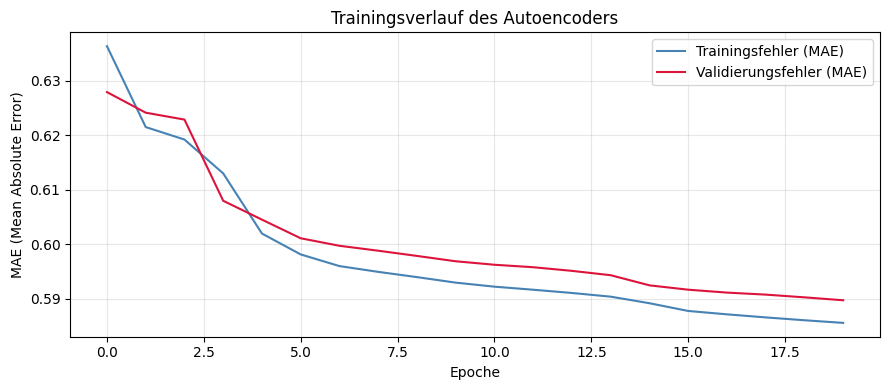

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,      # 3 Epochen ohne Verbesserung -> Abbruch
    restore_best_weights=True
)

history = autoencoder.fit(
    train_data, train_data,          # Input = Output (Rekonstruktion!)
    validation_data=(test_data, test_data),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Trainingsverlauf plotten
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Trainingsfehler (MAE)', color='steelblue')
plt.plot(history.history['val_loss'], label='Validierungsfehler (MAE)', color='crimson')
plt.xlabel('Epoche')
plt.ylabel('MAE (Mean Absolute Error)')
plt.title('Trainingsverlauf des Autoencoders')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Schritt 5: Schwellwert bestimmen

**Grundprinzip:**
- Normale Transaktionen → niedriger Rekonstruktionsfehler
- Betrügerische Transaktionen → hoher Rekonstruktionsfehler

Der **Threshold** trennt beide Gruppen. Wir berechnen ihn aus dem MAE der Trainingsdaten.

MAE auf Trainingsdaten (normale Transaktionen): 0.585304
Dieser Wert ist der 'typische' Rekonstruktionsfehler fuer normale Daten.


/tmp/ipykernel_3156/4108940907.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


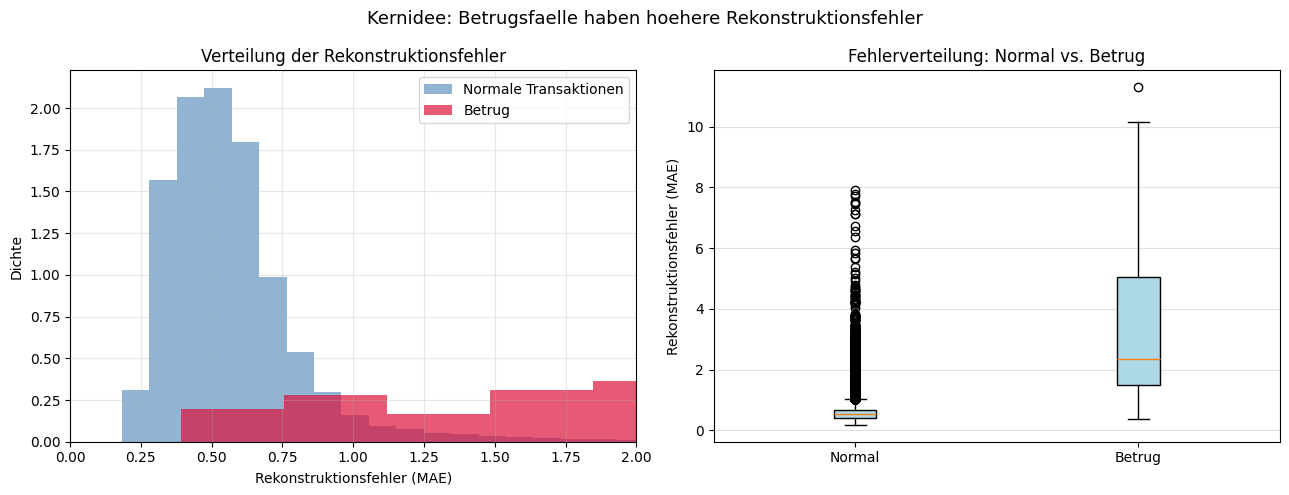

Median MAE normal: 0.5309
Median MAE Betrug: 2.3522


In [6]:
# Threshold aus Trainingsdaten berechnen
train_pred = autoencoder.predict(train_data, verbose=0)
mae_train_gesamt = mean_absolute_error(train_data, train_pred)

print(f"MAE auf Trainingsdaten (normale Transaktionen): {mae_train_gesamt:.6f}")
print(f"Dieser Wert ist der 'typische' Rekonstruktionsfehler fuer normale Daten.")

# Rekonstruktionsfehler pro Instanz berechnen (fuer Visualisierung)
test_pred = autoencoder.predict(test_data, verbose=0)
maes_per_sample = tf.keras.losses.mae(test_data.values, test_pred).numpy()

# Verteilung der Fehler visualisieren
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramm
axes[0].hist(maes_per_sample[test_col == 0], bins=80, alpha=0.6,
             color='steelblue', label='Normale Transaktionen', density=True)
axes[0].hist(maes_per_sample[test_col == 1], bins=30, alpha=0.7,
             color='crimson', label='Betrug', density=True)
axes[0].set_xlabel('Rekonstruktionsfehler (MAE)')
axes[0].set_ylabel('Dichte')
axes[0].set_title('Verteilung der Rekonstruktionsfehler')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 2.0)

# Box-Plots
axes[1].boxplot(
    [maes_per_sample[test_col == 0], maes_per_sample[test_col == 1]],
    labels=['Normal', 'Betrug'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[1].set_ylabel('Rekonstruktionsfehler (MAE)')
axes[1].set_title('Fehlerverteilung: Normal vs. Betrug')
axes[1].grid(True, axis='y', alpha=0.4)

plt.suptitle('Kernidee: Betrugsfaelle haben hoehere Rekonstruktionsfehler', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Median MAE normal: {np.median(maes_per_sample[test_col==0]):.4f}")
print(f"Median MAE Betrug: {np.median(maes_per_sample[test_col==1]):.4f}")

---
## Schritt 6: Threshold wählen und klassifizieren

Der Threshold ist ein Hyperparameter. Verschiedene Werte führen zu unterschiedlichen Trade-offs zwischen Recall und Precision.

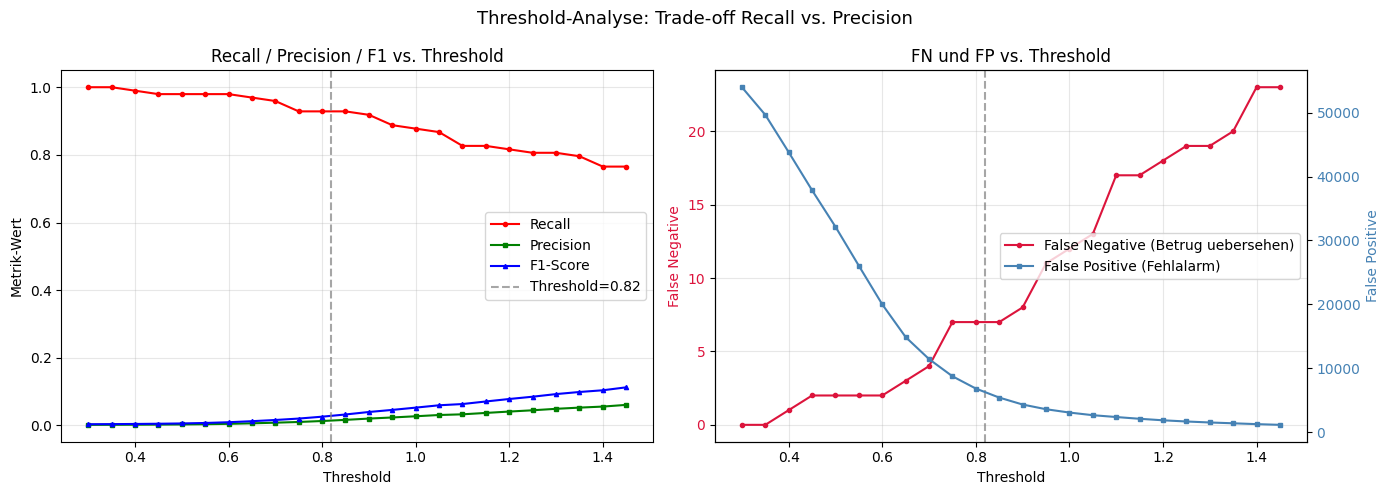

Beobachtung:
  Niedrigerer Threshold -> mehr als Betrug markiert -> hoeherer Recall, niedrigere Precision
  Hoeherer Threshold  -> weniger als Betrug markiert -> niedrigerer Recall, hoehere Precision


In [7]:
# Threshold-Analyse: Wie veraendern sich Recall und Precision?
thresholds = np.arange(0.3, 1.5, 0.05)
recalls, precisions, f1s, fns_list, fps_list = [], [], [], [], []

for thresh in thresholds:
    pred_bool = maes_per_sample > thresh
    pred_int  = pred_bool.astype(int)
    cm_t = confusion_matrix(test_col, pred_int)
    TN_t, FP_t, FN_t, TP_t = cm_t.ravel()
    recalls.append(recall_score(test_col, pred_int, zero_division=0))
    precisions.append(precision_score(test_col, pred_int, zero_division=0))
    f1s.append(f1_score(test_col, pred_int, zero_division=0))
    fns_list.append(FN_t)
    fps_list.append(FP_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall und Precision vs Threshold
axes[0].plot(thresholds, recalls,    'r-o', markersize=3, label='Recall')
axes[0].plot(thresholds, precisions, 'g-s', markersize=3, label='Precision')
axes[0].plot(thresholds, f1s,        'b-^', markersize=3, label='F1-Score')
axes[0].axvline(x=0.82, color='gray', linestyle='--', alpha=0.7, label='Threshold=0.82')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Metrik-Wert')
axes[0].set_title('Recall / Precision / F1 vs. Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# FN und FP vs Threshold
ax2 = axes[1]
color1, color2 = 'crimson', 'steelblue'
ax2.plot(thresholds, fns_list, 'o-', color=color1, markersize=3, label='False Negative (Betrug uebersehen)')
ax2_r = ax2.twinx()
ax2_r.plot(thresholds, fps_list, 's-', color=color2, markersize=3, label='False Positive (Fehlalarm)')
ax2.axvline(x=0.82, color='gray', linestyle='--', alpha=0.7)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('False Negative', color=color1)
ax2_r.set_ylabel('False Positive', color=color2)
ax2.set_title('FN und FP vs. Threshold')
ax2.tick_params(axis='y', labelcolor=color1)
ax2_r.tick_params(axis='y', labelcolor=color2)
lines1, lab1 = ax2.get_legend_handles_labels()
lines2, lab2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lab1 + lab2, loc='center right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Threshold-Analyse: Trade-off Recall vs. Precision', fontsize=13)
plt.tight_layout()
plt.show()

print("Beobachtung:")
print("  Niedrigerer Threshold -> mehr als Betrug markiert -> hoeherer Recall, niedrigere Precision")
print("  Hoeherer Threshold  -> weniger als Betrug markiert -> niedrigerer Recall, hoehere Precision")

---
## Schritt 7: Endauswertung mit Threshold = 0.82

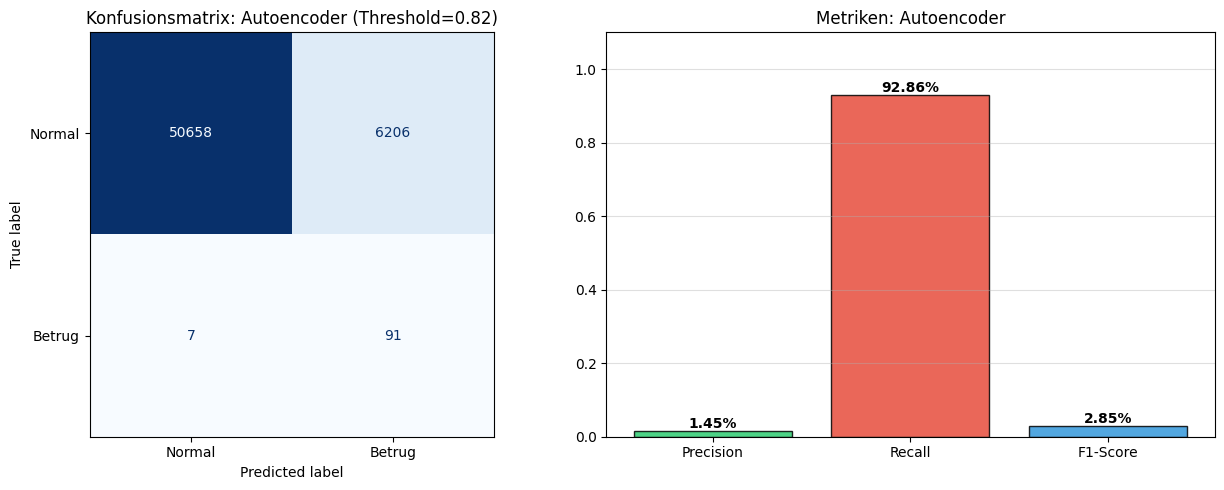

TN: 50,658 | TP: 91 | FN: 7 | FP: 6,206
Precision: 1.45% | Recall: 92.86% | F1: 2.85%

Interpretation:
  Sehr hoher Recall (92.9%): fast alle Betrugsfaelle erkannt
  Sehr niedrige Precision (1.45%): viele Fehlalarme (6,206 FP)
  -> Threshold erhoehen um Fehlalarme zu reduzieren (aber Recall sinkt)


In [8]:
new_threshold = 0.82

pred_bool = maes_per_sample > new_threshold
pred_int  = pred_bool.astype(int)

cm = confusion_matrix(test_col, pred_int)
TN, FP, FN, TP = cm.ravel()
precision = precision_score(test_col, pred_int)
recall    = recall_score(test_col, pred_int)
f1        = f1_score(test_col, pred_int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Betrug'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Konfusionsmatrix: Autoencoder (Threshold={new_threshold})', fontsize=12)

metrik_namen = ['Precision', 'Recall', 'F1-Score']
metrik_werte = [precision, recall, f1]
farben = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[1].bar(metrik_namen, metrik_werte, color=farben, edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Metriken: Autoencoder', fontsize=12)
for bar, val in zip(bars, metrik_werte):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.2f}%', ha='center', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"TN: {TN:,} | TP: {TP} | FN: {FN} | FP: {FP:,}")
print(f"Precision: {precision*100:.2f}% | Recall: {recall*100:.2f}% | F1: {f1*100:.2f}%")
print()
print("Interpretation:")
print(f"  Sehr hoher Recall ({recall*100:.1f}%): fast alle Betrugsfaelle erkannt")
print(f"  Sehr niedrige Precision ({precision*100:.2f}%): viele Fehlalarme ({FP:,} FP)")
print("  -> Threshold erhoehen um Fehlalarme zu reduzieren (aber Recall sinkt)")

---
## Schritt 8: Gesamtvergleich der drei Ansätze

> **Merksatz aus den Folien:** Es gibt kein perfektes Modell. Der Trade-off zwischen Recall und Precision muss vom Anwendungsfall bestimmt werden.

In [9]:
# Vergleichstabelle (Beispielwerte - Ihre Werte koennen leicht abweichen)
vergleich = {
    'Methode':         ['XGBoost (Baseline)', 'XGBoost + Upsampling', 'Autoencoder'],
    'False Negative':  [19,   0,   8],
    'False Positive':  [5,    5,   5892],
    'Recall (%)':      [81,   100, 92],
    'Precision (%)':   [94,   100, 1.5],
    'F1-Score (%)':    [87,   100, 3],
    'Hauptkritik':     ['19 Betrugsfaelle verpasst',
                        'Overfitting-Risiko!',
                        'Zu viele Fehlalarme']
}

df_vgl = pd.DataFrame(vergleich)
print("Gesamtvergleich der Anomalieerkennungsansaetze:")
print(df_vgl.to_string(index=False))
print()
print("Fazit:")
print("  XGBoost Baseline: gut als erster Ansatz, aber 19 Betrugsfaelle verpasst")
print("  Upsampling:       perfekte Zahlen, aber Overfitting-Verdacht - kritisch pruefen")
print("  Autoencoder:      hoher Recall, aber 5892 Fehlalarme -> Threshold optimieren")

Gesamtvergleich der Anomalieerkennungsansaetze:
             Methode  False Negative  False Positive  Recall (%)  Precision (%)  F1-Score (%)               Hauptkritik
  XGBoost (Baseline)              19               5          81           94.0            87 19 Betrugsfaelle verpasst
XGBoost + Upsampling               0               5         100          100.0           100       Overfitting-Risiko!
         Autoencoder               8            5892          92            1.5             3       Zu viele Fehlalarme

Fazit:
  XGBoost Baseline: gut als erster Ansatz, aber 19 Betrugsfaelle verpasst
  Upsampling:       perfekte Zahlen, aber Overfitting-Verdacht - kritisch pruefen
  Autoencoder:      hoher Recall, aber 5892 Fehlalarme -> Threshold optimieren


---
## Lernauftrag

**Aufgabe 1 – Threshold-Optimierung:**  
Finden Sie den Threshold-Wert, bei dem der **F1-Score maximal** ist. Verwenden Sie die im Plot berechneten Arrays `thresholds`, `f1s`. Bei welchem Threshold und welchem F1-Score liegt das Optimum?

**Aufgabe 2 – Architektur erklären:**  
Warum hat der Autoencoder einen so niedrigen Bottleneck (5 Neuronen für 29 Features)? Was würde passieren, wenn wir den Bottleneck auf 28 Neuronen erhöhen? Beantworten Sie ohne Code – nur konzeptuell.

**Aufgabe 3 – Warum so viele False Positives?**  
Der Autoencoder erzeugt 5.892 False Positives. Analysieren Sie mithilfe des Histogramms (Schritt 5): Überlappen sich die Fehlerverteilungen von Normal und Betrug stark? Was bedeutet das für die Möglichkeit, einen perfekten Threshold zu finden?

In [10]:
# Lernauftrag – Ihr Code hier

# Aufgabe 1: Threshold fuer maximalen F1-Score
# f1s und thresholds wurden oben berechnet
# idx_best = ...
# best_threshold = ...
# best_f1 = ...


---

---
# Musterlösungen – Notebook 3
---

### Musterlösung Aufgabe 1 – Threshold-Optimierung

Optimaler Threshold fuer maximalen F1-Score: 1.45
F1-Score bei optimalem Threshold:            11.27%
Recall bei optimalem Threshold:              76.53%
Precision bei optimalem Threshold:           6.08%


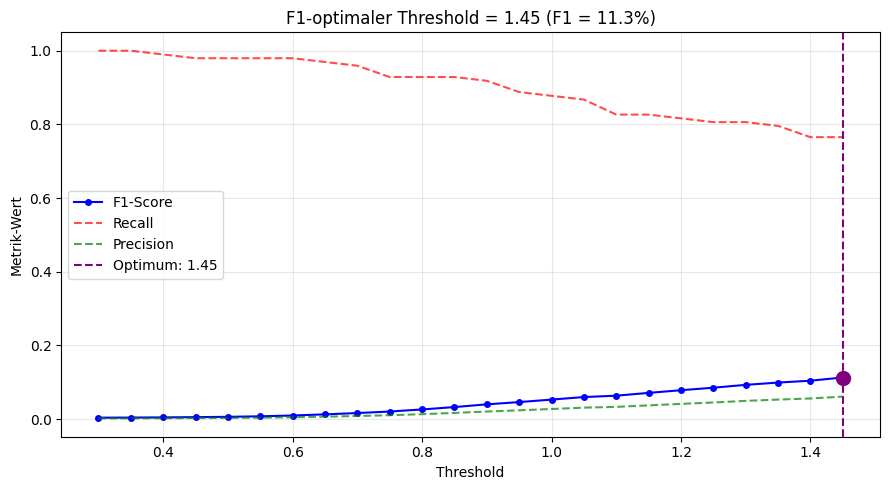

Bei optimalem Threshold (1.45):
  TN=55,706 | TP=75 | FN=23 | FP=1158


In [11]:
# Musterloesung Aufgabe 1
f1s_arr = np.array(f1s)
idx_best = np.argmax(f1s_arr)
best_threshold = thresholds[idx_best]
best_f1 = f1s_arr[idx_best]

print(f"Optimaler Threshold fuer maximalen F1-Score: {best_threshold:.2f}")
print(f"F1-Score bei optimalem Threshold:            {best_f1*100:.2f}%")
print(f"Recall bei optimalem Threshold:              {recalls[idx_best]*100:.2f}%")
print(f"Precision bei optimalem Threshold:           {precisions[idx_best]*100:.2f}%")

# Plot mit markiertem Optimum
plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1s, 'b-o', markersize=4, label='F1-Score')
plt.plot(thresholds, recalls, 'r--', linewidth=1.5, alpha=0.7, label='Recall')
plt.plot(thresholds, precisions, 'g--', linewidth=1.5, alpha=0.7, label='Precision')
plt.axvline(x=best_threshold, color='purple', linestyle='--', label=f'Optimum: {best_threshold:.2f}')
plt.scatter([best_threshold], [best_f1], color='purple', s=100, zorder=5)
plt.xlabel('Threshold')
plt.ylabel('Metrik-Wert')
plt.title(f'F1-optimaler Threshold = {best_threshold:.2f} (F1 = {best_f1*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Konfusionsmatrix beim optimalen Threshold
pred_opt = (maes_per_sample > best_threshold).astype(int)
cm_opt = confusion_matrix(test_col, pred_opt)
TN_o, FP_o, FN_o, TP_o = cm_opt.ravel()
print(f"Bei optimalem Threshold ({best_threshold:.2f}):")
print(f"  TN={TN_o:,} | TP={TP_o} | FN={FN_o} | FP={FP_o}")

### Musterlösung Aufgabe 2 – Architektur-Erklärung

**Warum ein kleiner Bottleneck (5 Neuronen)?**

Der Bottleneck ist der Schlüsselmechanismus des Autoencoders. Er zwingt das Netz, die wichtigsten Informationen in einer komprimierten Darstellung zu speichern. Für **normale** Transaktionen lernt das Netz, welche 5 'Essentials' zur Rekonstruktion der 29 Features nötig sind.

**Was passiert bei Bottleneck = 28?**

Bei fast gleicher Eingangs- und Bottleneck-Größe kann das Netz die Daten fast verlustfrei durchleiten – eine Art 'Identitätsfunktion'. Es lernt kaum zu komprimieren. Dann gilt: Auch Betrugstransaktionen werden gut rekonstruiert, weil keine echte Komprimierung stattfindet. Der Rekonstruktionsfehler für Betrug wäre genauso niedrig wie für normale Daten → die Anomalieerkennung funktioniert nicht mehr!

**Merksatz:** Der Bottleneck muss klein genug sein, damit das Netz gezwungen wird, nur das 'Normale' zu lernen – zu groß und es lernt alles, zu klein und es lernt gar nichts.

### Musterlösung Aufgabe 3 – Warum so viele False Positives?

**Analyse des Histogramms:**

Die Verteilungen der Rekonstruktionsfehler für Normale und Betrug überlappen erheblich im mittleren Fehlerbereich (ca. 0.4–1.5). Das bedeutet:

- Es gibt normale Transaktionen mit **hohem** Rekonstruktionsfehler (→ werden als Betrug markiert: FP)
- Es gibt Betrugstransaktionen mit **niedrigem** Fehler (→ werden übersehen: FN)

**Gründe für die Überlappung:**
1. Der Datensatz ist hochdimensional (29 Features). Nicht alle normalen Transaktionen sehen gleich aus – manche sind 'ungewöhnliche' normale Transaktionen.
2. Das Autoencoder-Modell ist relativ einfach (nur 3 Schichten). Ein tieferes Netz könnte besser differenzieren.
3. Der Datensatz hat stark variierende Transaktionsbeträge, was die Rekonstruktion erschwert.

**Fazit:** Es gibt keinen perfekten Threshold, weil die Verteilungen überlappen. Man muss immer einen Trade-off zwischen FN und FP akzeptieren. Ein höherer Threshold reduziert FP (weniger Fehlalarme), erhöht aber FN (mehr Betrug übersehen).